# Inspect Raw Data
Lightweight checks for data availability, shapes, and a quick visual sanity check.

This notebook does not modify any data. It loads a small subset to keep runtime fast.

In [7]:
import sys
from unittest.mock import MagicMock

# Staintools imports Vahadane by default; avoid spams dependency for Macenko-only use.
sys.modules['spams'] = MagicMock()

import numpy as np
import matplotlib.pyplot as plt
import cuml, cudf, cupy
import sklearn, lightgbm, optuna
import skimage, cv2, staintools

print("All imports OK")
print("cuML version:", cuml.__version__)
print("CuPy CUDA:", cupy.cuda.runtime.runtimeGetVersion())

All imports OK
cuML version: 25.12.00
CuPy CUDA: 12090


In [12]:
import numpy as np

base = "../data/raw"
print("Base folder:", base)

for fold in [1, 2, 3]:
    fold_dir = f"{base}/Fold{fold}/images/fold{fold}"
    images = np.load(f"{fold_dir}/images.npy", mmap_mode="r")
    masks = np.load(f"{base}/Fold{fold}/masks/fold{fold}/masks.npy", mmap_mode="r")
    types = np.load(f"{fold_dir}/types.npy", allow_pickle=True)

    print(f"\nFold {fold}:")
    print(f"  images: {images.shape} dtype={images.dtype}")
    print(f"  masks:  {masks.shape}  dtype={masks.dtype}")
    print(f"  types:  {types.shape}")

    assert images.shape[1:] == (256, 256, 3), "Wrong image shape"
    assert masks.shape[1:] == (256, 256, 6), "Wrong mask shape -- check channel order"
    assert images.shape[0] == masks.shape[0], "Image/mask count mismatch"

    # Use a tiny slice to avoid loading full arrays into RAM.
    for c in range(5):
        nonzero_frac = (masks[:2, :, :, c] > 0).mean()
        print(f"  channel {c} nonzero fraction (first 2 imgs): {nonzero_frac:.3f}")
    bg_frac = (masks[:2, :, :, 5] > 0).mean()
    print(f"  channel 5 (background) nonzero fraction: {bg_frac:.3f}")

Base folder: ../data/raw

Fold 1:
  images: (2656, 256, 256, 3) dtype=float64
  masks:  (2656, 256, 256, 6)  dtype=float64
  types:  (2656,)
  channel 0 nonzero fraction (first 2 imgs): 0.094
  channel 1 nonzero fraction (first 2 imgs): 0.009
  channel 2 nonzero fraction (first 2 imgs): 0.011
  channel 3 nonzero fraction (first 2 imgs): 0.000
  channel 4 nonzero fraction (first 2 imgs): 0.000
  channel 5 (background) nonzero fraction: 0.885

Fold 2:
  images: (2523, 256, 256, 3) dtype=float64
  masks:  (2523, 256, 256, 6)  dtype=float64
  types:  (2523,)
  channel 0 nonzero fraction (first 2 imgs): 0.048
  channel 1 nonzero fraction (first 2 imgs): 0.000
  channel 2 nonzero fraction (first 2 imgs): 0.075
  channel 3 nonzero fraction (first 2 imgs): 0.000
  channel 4 nonzero fraction (first 2 imgs): 0.000
  channel 5 (background) nonzero fraction: 0.877

Fold 3:
  images: (2722, 256, 256, 3) dtype=float64
  masks:  (2722, 256, 256, 6)  dtype=float64
  types:  (2722,)
  channel 0 nonzero

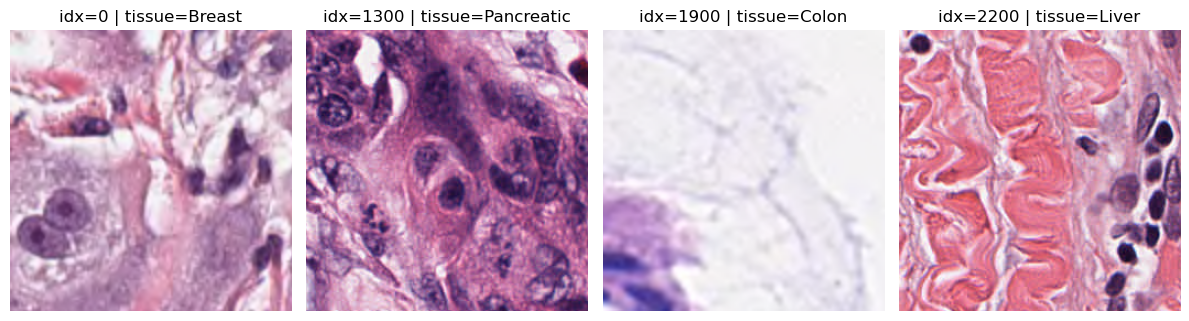

In [13]:
import numpy as np
import matplotlib.pyplot as plt

fold = 1
fold_dir = f"{base}/Fold{fold}/images/fold{fold}"
images = np.load(f"{fold_dir}/images.npy", mmap_mode="r")
types = np.load(f"{fold_dir}/types.npy", allow_pickle=True)

idxs = [0, 1300, 1900, 2200]
fig, axes = plt.subplots(1, len(idxs), figsize=(12, 4))
for ax, idx in zip(axes, idxs):
    img = images[idx].astype(np.uint8)
    ax.imshow(img)
    ax.set_title(f"idx={idx} | tissue={types[idx]}")
    ax.axis("off")
plt.tight_layout()